In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [4]:
filters = {
    'config.ema_steps': 50,
    'config.tag': 'eca_rules',
    'config.T': 10000,
}
runs = get_runs("shikai/requential", filters)
runs = runs.sort_values(by=['meta/rule'])

In [5]:
metrics = runs['history'].apply(lambda x: x.iloc[-1])
runs = runs.join(metrics)
runs['K_req'] = runs['K_req'] / np.log(2)
runs['K_auc'] = runs['K_auc'] / np.log(2)

In [6]:
rules = [0, 32, 160, 232, # class 1: convergent
    4, 15, 108, 218, # class 2: periodic
    22, 30, 126, 150, # class 3: chaotic
    41, 54, 106, 110] # class 4: complex

runs['class'] = runs['meta/rule'].apply(lambda x: 'I' if x in rules[:4] else 'II' if x in rules[4:8] else 'III' if x in rules[8:12] else 'IV')
rule_markers = {
    0: 'o', 32: 'v', 160: '^', 232: '<',
    4: '>', 15: 's', 108: 'p', 218: '*',
    22: 'h', 30: 'H', 126: 'D', 150: 'd',
    41: 'P', 54: 'X', 106: '8', 110: 'D'
}
runs['marker'] = runs['meta/rule'].apply(lambda x: rule_markers.get(x, 'o'))
runs = runs.sort_values(by='class')

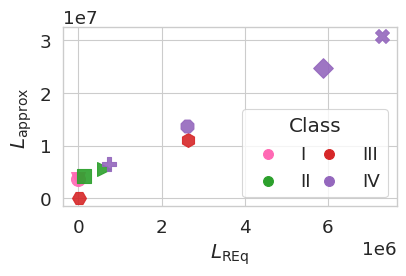

In [7]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

fig, ax = plt.subplots(1, 1, figsize=(4.3, 3))

class_colors = {
    'I': "#ff69b4",
    'II': "#2ca02c",
    'III': "#d62728",
    'IV': "#9467bd",
}

for class_ in runs['class'].unique():
    df_class = runs[runs['class'] == class_]
    for rule in df_class['meta/rule'].unique():
        df_rule = df_class[df_class['meta/rule'] == rule]
        rule_color = class_colors[df_rule['class'].iloc[0]]
        ax.scatter(df_rule['K_req'], df_rule['K_auc'], c=rule_color, marker=df_rule['marker'].iloc[0], s=100, alpha=0.9)

ax.set_xlabel(r'$L_\mathrm{REq}$')
ax.set_ylabel(r'$L_\mathrm{approx}$')

for class_ in runs['class'].unique():
    ax.scatter([], [], c=class_colors[class_], s=50, label=f'{class_}')

xlim = ax.get_xlim()
ax.set_xlim(None, xlim[1])

ax.legend(ncol=2, columnspacing=0., title='Class', loc='lower right')
plt.tight_layout()
plt.show()